In [1]:
!pip install qiskit==1.3.0 qiskit-aer==0.15.0 scikit-learn matplotlib scipy tqdm scikit-optimize optuna numpy==2.0.0 transformers==4.44.2 torch -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.9/60.9 kB 2.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.7/43.7 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.7/6.7 MB 9.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 19.0/19.0 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 58.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 35.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.6/49.6 MB 34.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 12.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of

In [2]:
import numpy as np
import qiskit, qiskit_aer
print(np.__version__)
print(qiskit.__version__)
print(qiskit_aer.__version__)
import torch
print("torch", torch.__version__, "cuda available:", torch.cuda.is_available())

2.0.2
1.3.0
0.15.0
torch 2.10.0+cpu cuda available: False


In [3]:
from __future__ import annotations
import math
import re
import time
import warnings
from dataclasses import dataclass
from typing import Callable, Dict, List, Optional, Tuple

import matplotlib.pyplot as plt
import numpy as np
import torch
from qiskit import QuantumCircuit
from qiskit.circuit import ParameterVector
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, depolarizing_error
from qiskit_aer.primitives import Sampler as AerSampler
from scipy.stats import mannwhitneyu, norm as scipy_norm
from sklearn.datasets import load_breast_cancer, load_digits
from sklearn.ensemble import RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import ConstantKernel, Matern, WhiteKernel
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm import trange

warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)


class HyperparameterEncoder:
    def __init__(self, search_space: dict):
        self.search_space = search_space
        self.param_names = list(search_space.keys())
        self.qubit_ranges: Dict[str, Tuple[int, int]] = {}
        self.num_values: Dict[str, int] = {}
        self.num_qubits_per_param: Dict[str, int] = {}
        self.grid_values: Dict[str, list] = {}
        self._stride: Dict[str, int] = {}
        self._cached_vectors: Optional[np.ndarray] = None

        cursor = 0
        total = 1
        for name in self.param_names:
            spec = search_space[name]
            if spec["type"] == "continuous":
                values = np.linspace(
                    float(spec["low"]),
                    float(spec["high"]),
                    int(spec["num_points"]),
                ).tolist()
            elif spec["type"] == "discrete":
                values = list(spec["values"])
            else:
                raise ValueError(f"Unsupported type for parameter '{name}'.")
            n_vals = len(values)
            n_q = int(math.ceil(math.log2(max(2, n_vals))))
            self.grid_values[name] = values
            self.num_values[name] = n_vals
            self.num_qubits_per_param[name] = n_q
            self.qubit_ranges[name] = (cursor, cursor + n_q)
            cursor += n_q
            total *= n_vals

        self.total_qubits = cursor
        self.total_configs = int(total)

        stride = 1
        for name in reversed(self.param_names):
            self._stride[name] = stride
            stride *= self.num_values[name]

    def bitstring_to_config(self, bitstring: str) -> dict:
        config = {}
        for name in self.param_names:
            start, end = self.qubit_ranges[name]
            idx = int(bitstring[start:end], 2) if end > start else 0
            idx = min(idx, self.num_values[name] - 1)
            config[name] = self.grid_values[name][idx]
        return config

    def config_to_index(self, config: dict) -> int:
        idx = 0
        for name in self.param_names:
            values = self.grid_values[name]
            v = config[name]
            try:
                local = values.index(v)
            except ValueError:
                local = int(np.argmin(np.abs(
                    np.array(values, dtype=float) - float(v))))
            idx += local * self._stride[name]
        return int(idx)

    def bitstring_to_index(self, bitstring: str) -> int:
        return self.config_to_index(self.bitstring_to_config(bitstring))

    def index_to_config(self, index: int) -> dict:
        config, remainder = {}, int(index)
        for name in self.param_names:
            stride = self._stride[name]
            local = min(remainder // stride, self.num_values[name] - 1)
            remainder = remainder % stride
            config[name] = self.grid_values[name][local]
        return config

    def config_to_normalized_vector(self, config: dict) -> np.ndarray:
        out = []
        for name in self.param_names:
            values = self.grid_values[name]
            v = config[name]
            try:
                local = values.index(v)
            except (ValueError, AttributeError):
                local = int(np.argmin(np.abs(
                    np.array(values, dtype=float) - float(v))))
            out.append(local / max(1, len(values) - 1))
        return np.array(out, dtype=float)

    def all_normalized_vectors(self) -> np.ndarray:
        if self._cached_vectors is None:
            self._cached_vectors = np.array([
                self.config_to_normalized_vector(self.index_to_config(i))
                for i in range(self.total_configs)
            ], dtype=float)
        return self._cached_vectors

    def get_correlation_pairs(self) -> List[Tuple[int, int]]:
        pairs = []
        for i in range(len(self.param_names) - 1):
            left = self.param_names[i]
            right = self.param_names[i + 1]
            _, left_end = self.qubit_ranges[left]
            right_start, _ = self.qubit_ranges[right]
            pairs.append((left_end - 1, right_start))
        return pairs


class VariationalSurrogate:
    def __init__(self, num_qubits: int, num_layers: int, encoder: HyperparameterEncoder):
        self.num_qubits = num_qubits
        self.num_layers = num_layers
        self.encoder = encoder
        self.correlation_pairs = encoder.get_correlation_pairs()
        self._build()

    def _build(self):
        n = self.num_qubits
        pairs = len(self.correlation_pairs)
        n_params = self.num_layers * (3 * n + pairs) + n
        self.parameters = ParameterVector("theta", length=n_params)
        qc = QuantumCircuit(n)
        p = 0
        for _ in range(self.num_layers):
            for q in range(n):
                qc.ry(self.parameters[p], q)
                p += 1
            for q in range(n):
                qc.rz(self.parameters[p], q)
                p += 1
            for q in range(n - 1):
                qc.cx(q, q + 1)
            for ctrl, tgt in self.correlation_pairs:
                qc.crz(self.parameters[p], ctrl, tgt)
                p += 1
            for q in range(n):
                qc.ry(self.parameters[p], q)
                p += 1
        for q in range(n):
            qc.ry(self.parameters[p], q)
            p += 1
        self.circuit = qc

    def bind(self, values: np.ndarray) -> QuantumCircuit:
        return self.circuit.assign_parameters(dict(zip(self.parameters, values)))

    def get_num_parameters(self) -> int:
        return len(self.parameters)


class GaussianProcessSurrogate:
    def __init__(self, noise_level: float = 1e-6, ucb_threshold: int = 5):
        kernel = (
            ConstantKernel(1.0, constant_value_bounds=(1e-3, 1e3))
            * Matern(nu=2.5, length_scale=1.0, length_scale_bounds=(1e-2, 1e2))
            + WhiteKernel(noise_level=noise_level, noise_level_bounds=(1e-8, 1e-1))
        )
        self.gp = GaussianProcessRegressor(
            kernel=kernel,
            n_restarts_optimizer=3,
            normalize_y=True,
            random_state=42,
        )
        self.X_obs: List[np.ndarray] = []
        self.y_obs: List[float] = []
        self.is_fitted = False
        self.ucb_threshold = ucb_threshold

    def add(self, x: np.ndarray, y: float):
        self.X_obs.append(x.copy())
        self.y_obs.append(float(y))

    def fit(self):
        if len(self.X_obs) < 3:
            return
        self.gp.fit(np.array(self.X_obs), np.array(self.y_obs))
        self.is_fitted = True

    def predict(self, X: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        if not self.is_fitted:
            return np.zeros(len(X)), np.ones(len(X))
        mean, std = self.gp.predict(X, return_std=True)
        return mean, np.maximum(std, 1e-9)

    def acquisition(self, X: np.ndarray, xi: float = 0.01,
                    ucb_beta: float = 2.0) -> np.ndarray:
        if self.n_obs < self.ucb_threshold:
            return self.ucb(X, beta=ucb_beta)
        return self.expected_improvement(X, xi=xi)

    def expected_improvement(self, X: np.ndarray, xi: float = 0.01) -> np.ndarray:
        mean, std = self.predict(X)
        f_best = float(np.max(self.y_obs)) if self.y_obs else 0.0
        improvement = mean - f_best - xi
        Z = improvement / std
        ei = improvement * scipy_norm.cdf(Z) + std * scipy_norm.pdf(Z)
        return np.maximum(ei, 0.0)

    def ucb(self, X: np.ndarray, beta: float = 2.0) -> np.ndarray:
        mean, std = self.predict(X)
        return mean + beta * std

    @property
    def n_obs(self) -> int:
        return len(self.y_obs)


class ParameterShiftAcquisitionOptimizer:
    def __init__(
        self,
        ansatz: VariationalSurrogate,
        encoder: HyperparameterEncoder,
        backend,
        learning_rate: float = 0.1,
        grad_shots: int = 512,
        sample_shots: int = 1024,
        max_grad_norm: float = 1.0,
        gradient_repeats: int = 2,
    ):
        self.ansatz = ansatz
        self.encoder = encoder
        self.backend = backend
        self.learning_rate = learning_rate
        self.grad_shots = grad_shots
        self.sample_shots = sample_shots
        self.max_grad_norm = max_grad_norm
        self.gradient_repeats = gradient_repeats

        self.beta1 = 0.9
        self.beta2 = 0.999
        self.eps = 1e-8
        self.t = 0
        self.m: Optional[np.ndarray] = None
        self.v: Optional[np.ndarray] = None

        self._sampler = AerSampler()
        self._sampler.set_options(backend=backend)

    def _run(self, params: np.ndarray, shots: int) -> np.ndarray:
        circuit = self.ansatz.bind(params)
        measured = circuit.copy()
        measured.measure_all()
        result = self._sampler.run([measured], shots=shots).result()
        probs = np.zeros(self.encoder.total_configs, dtype=float)
        for outcome, prob in result.quasi_dists[0].items():
            bs = format(int(outcome), f"0{self.encoder.total_qubits}b")
            idx = self.encoder.bitstring_to_index(bs)
            probs[idx] += max(0.0, float(prob))
        total = probs.sum()
        if total > 0:
            probs /= total
        else:
            probs = np.full(len(probs), 1.0 / len(probs))
        return probs

    def _run_averaged(self, params: np.ndarray) -> np.ndarray:
        probs = np.zeros(self.encoder.total_configs, dtype=float)
        for _ in range(self.gradient_repeats):
            probs += self._run(params, self.grad_shots)
        return probs / self.gradient_repeats

    def _expectation(self, params: np.ndarray, weights: np.ndarray) -> float:
        probs = self._run_averaged(params)
        return float(np.dot(probs, weights))

    def parameter_shift_gradient(self, params: np.ndarray,
                                  weights: np.ndarray) -> np.ndarray:
        grad = np.zeros_like(params, dtype=float)
        shift = np.pi / 2.0
        for i in range(len(params)):
            p_plus = params.copy()
            p_plus[i] += shift
            p_minus = params.copy()
            p_minus[i] -= shift
            grad[i] = 0.5 * (
                self._expectation(p_plus, weights)
                - self._expectation(p_minus, weights)
            )
        return grad

    def train_on_acquisition(
        self,
        params: np.ndarray,
        gp: GaussianProcessSurrogate,
        n_steps: int = 3,
        xi: float = 0.01,
        ucb_beta: float = 2.0,
    ) -> Tuple[np.ndarray, List[float]]:
        all_vecs = self.encoder.all_normalized_vectors()
        acq = gp.acquisition(all_vecs, xi=xi, ucb_beta=ucb_beta)
        acq_max = acq.max()
        if acq_max > 1e-10:
            weights = acq / acq_max
        else:
            weights = np.ones(self.encoder.total_configs)
            weights /= len(weights)

        current = params.copy()
        loss_history = []

        for _ in range(n_steps):
            grad_ascent = self.parameter_shift_gradient(current, weights)
            grad_loss = -grad_ascent
            norm = np.linalg.norm(grad_loss)
            if norm > self.max_grad_norm:
                grad_loss = grad_loss * self.max_grad_norm / norm

            if self.m is None:
                self.m = np.zeros_like(current)
                self.v = np.zeros_like(current)
            self.t += 1
            self.m = self.beta1 * self.m + (1 - self.beta1) * grad_loss
            self.v = self.beta2 * self.v + (1 - self.beta2) * grad_loss ** 2
            m_hat = self.m / (1 - self.beta1 ** self.t)
            v_hat = self.v / (1 - self.beta2 ** self.t)
            current = current - self.learning_rate * m_hat / (np.sqrt(v_hat) + self.eps)
            loss_history.append(-self._expectation(current, weights))

        return current, loss_history

    def entropy(self, params: np.ndarray) -> float:
        probs = self._run(params, self.sample_shots)
        return float(-(probs * np.log2(probs + 1e-12)).sum())

    def sample(
        self,
        params: np.ndarray,
        batch_size: int,
        temperature: float = 1.0,
        visited: Optional[set] = None,
    ) -> List[dict]:
        probs = self._run(params, self.sample_shots)
        scaled = probs ** (1.0 / max(1e-6, float(temperature)))
        if visited:
            for idx in visited:
                if 0 <= idx < len(scaled):
                    scaled[idx] = 0.0
        total = scaled.sum()
        if total <= 0:
            return []
        scaled /= total
        k = min(batch_size, int(np.count_nonzero(scaled)))
        if k == 0:
            return []
        chosen = np.random.choice(
            np.arange(len(scaled)), size=k, replace=False, p=scaled)
        return [self.encoder.index_to_config(int(i)) for i in chosen]


class QuantumBayesianOptimizer:
    def __init__(
        self,
        objective_fn: Callable,
        search_space: dict,
        num_layers: int = 2,
        max_iterations: int = 30,
        batch_size: int = 3,
        grad_shots: int = 512,
        sample_shots: int = 1024,
        noise_model=None,
        learning_rate: float = 0.1,
        vqc_steps_per_iter: int = 3,
        gradient_repeats: int = 2,
        xi_start: float = 0.05,
        xi_end: float = 0.005,
        ucb_beta: float = 2.0,
        entropy_threshold: float = 1.5,
        acq_threshold: float = 0.001,
        min_iter_before_convergence: int = 8,
        max_time_seconds: float = 7200.0,
        warm_start_n: int = 5,
        verbose: bool = True,
        random_seed: int = 42,
    ):
        self.objective_fn = objective_fn
        self.search_space = search_space
        self.max_iterations = max_iterations
        self.batch_size = batch_size
        self.vqc_steps_per_iter = vqc_steps_per_iter
        self.xi_start = xi_start
        self.xi_end = xi_end
        self.ucb_beta = ucb_beta
        self.entropy_threshold = entropy_threshold
        self.acq_threshold = acq_threshold
        self.min_iter_before_convergence = min_iter_before_convergence
        self.max_time_seconds = max_time_seconds
        self.warm_start_n = warm_start_n
        self.verbose = verbose

        np.random.seed(random_seed)

        self.encoder = HyperparameterEncoder(search_space)
        assert self.encoder.total_configs <= 128, (
            f"total_configs={self.encoder.total_configs} too large; "
            f"keep at or below 64 for reliable VQC training."
        )
        self.num_qubits = self.encoder.total_qubits
        self.ansatz = VariationalSurrogate(
            self.num_qubits, num_layers, self.encoder)

        backend = (AerSimulator(noise_model=noise_model)
                   if noise_model is not None
                   else AerSimulator(method="statevector"))
        self.backend = backend

        self.gp = GaussianProcessSurrogate(noise_level=1e-6, ucb_threshold=5)
        self.acq_optimizer = ParameterShiftAcquisitionOptimizer(
            ansatz=self.ansatz,
            encoder=self.encoder,
            backend=backend,
            learning_rate=learning_rate,
            grad_shots=grad_shots,
            sample_shots=sample_shots,
            gradient_repeats=gradient_repeats,
        )

        if self.verbose:
            n_p = self.ansatz.get_num_parameters()
            print(f"Search space: {self.encoder.total_configs} configs, "
                  f"{self.num_qubits} qubits, {n_p} circuit parameters")
            print(f"Max possible entropy: {math.log2(self.encoder.total_configs):.2f} bits")

    def _warm_start(self, n: int):
        chosen = set()
        center_idx = [self.encoder.num_values[name] // 2
                      for name in self.encoder.param_names]
        center_cfg = {name: self.encoder.grid_values[name][center_idx[i]]
                      for i, name in enumerate(self.encoder.param_names)}
        chosen.add(self.encoder.config_to_index(center_cfg))

        for pi, name in enumerate(self.encoder.param_names):
            nv = self.encoder.num_values[name]
            for extreme in [0, nv - 1]:
                cfg = {
                    pname: self.encoder.grid_values[pname][
                        extreme if j == pi else center_idx[j]]
                    for j, pname in enumerate(self.encoder.param_names)
                }
                chosen.add(self.encoder.config_to_index(cfg))
            if len(chosen) >= n:
                break

        remaining = n - len(chosen)
        if remaining > 0:
            available = np.setdiff1d(
                np.arange(self.encoder.total_configs), list(chosen))
            fill = np.random.choice(
                available, size=min(remaining, len(available)), replace=False)
            for idx in fill:
                chosen.add(int(idx))

        visited = set()
        observations = []
        for idx in list(chosen)[:n]:
            cfg = self.encoder.index_to_config(int(idx))
            score = float(self.objective_fn(cfg))
            self.gp.add(
                self.encoder.config_to_normalized_vector(cfg), score)
            visited.add(int(idx))
            observations.append((int(idx), score))
        self.gp.fit()
        return visited, observations

    def optimize(self) -> dict:
        start_time = time.time()
        params = np.random.uniform(
            0, 2 * np.pi, self.ansatz.get_num_parameters())
        best_score = -np.inf
        best_config = None
        history = []

        if self.verbose:
            print(f"Warm-starting with {self.warm_start_n} evaluations")
        visited, observations = self._warm_start(n=self.warm_start_n)
        for idx, score in observations:
            if score > best_score:
                best_score = score
                best_config = self.encoder.index_to_config(idx)

        if self.verbose:
            print(f"Warm-start best score: {best_score:.4f}")
            print(f"Running {self.max_iterations} optimization iterations")

        iterator = trange(
            self.max_iterations, disable=not self.verbose, desc="VQC-BO")

        for iteration in iterator:
            elapsed = time.time() - start_time
            if elapsed > self.max_time_seconds:
                if self.verbose:
                    print("Time limit reached, stopping")
                break

            progress = iteration / max(1, self.max_iterations - 1)
            xi = self.xi_start + (self.xi_end - self.xi_start) * progress
            temperature = max(0.7, 1.2 - 0.4 * progress)
            using_ucb = self.gp.n_obs < self.gp.ucb_threshold

            params, loss_history = self.acq_optimizer.train_on_acquisition(
                params, self.gp,
                n_steps=self.vqc_steps_per_iter,
                xi=xi,
                ucb_beta=self.ucb_beta,
            )

            sampled = self.acq_optimizer.sample(
                params, self.batch_size, temperature, visited)
            if not sampled:
                if self.verbose:
                    print("Sampling exhausted")
                break

            iter_scores = []
            for cfg in sampled:
                idx = self.encoder.config_to_index(cfg)
                visited.add(idx)
                score = float(self.objective_fn(cfg))
                iter_scores.append(score)
                self.gp.add(
                    self.encoder.config_to_normalized_vector(cfg), score)
                if score > best_score:
                    best_score = score
                    best_config = dict(cfg)

            self.gp.fit()
            entropy = self.acq_optimizer.entropy(params)
            all_vecs = self.encoder.all_normalized_vectors()
            if self.gp.is_fitted:
                acq_vals = self.gp.acquisition(
                    all_vecs, xi=xi, ucb_beta=self.ucb_beta)
                max_acq = float(acq_vals.max())
            else:
                max_acq = 1.0

            history.append({
                "iteration": iteration,
                "scores": iter_scores,
                "best_score": float(best_score),
                "best_config": best_config,
                "entropy": float(entropy),
                "temperature": float(temperature),
                "xi": float(xi),
                "max_acq": max_acq,
                "vqc_loss_final": float(loss_history[-1]) if loss_history else 0.0,
                "gp_n_obs": self.gp.n_obs,
                "using_ucb": using_ucb,
                "elapsed_sec": elapsed,
            })

            if self.verbose:
                tag = "UCB" if using_ucb else "EI"
                iterator.set_postfix(
                    best=f"{best_score:.4f}",
                    H=f"{entropy:.2f}",
                    acq=f"{max_acq:.4f}({tag})",
                )

            if (iteration >= self.min_iter_before_convergence
                    and entropy < self.entropy_threshold
                    and max_acq < self.acq_threshold):
                if self.verbose:
                    print(f"Converged at iteration {iteration}: "
                          f"entropy={entropy:.3f}, max_acq={max_acq:.5f}")
                break

        return {
            "best_config": best_config,
            "best_score": float(best_score),
            "history": history,
            "num_iterations": len(history),
            "final_entropy": (float(history[-1]["entropy"])
                              if history else float("nan")),
            "total_evaluations": len(visited),
            "gp_observations": self.gp.n_obs,
            "runtime_sec": time.time() - start_time,
        }


def create_depolarizing_noise(probability: float) -> NoiseModel:
    nm = NoiseModel()
    nm.add_all_qubit_quantum_error(
        depolarizing_error(probability, 1), ["ry", "rz"])
    nm.add_all_qubit_quantum_error(
        depolarizing_error(probability, 2), ["cx", "crz"])
    return nm


def diagnose_barren_plateau(
    encoder_factory,
    qubit_counts: List[int],
    num_layers: int = 2,
    n_samples: int = 30,
    shots: int = 512,
    random_seed: int = 42,
) -> dict:
    np.random.seed(random_seed)
    backend = AerSimulator(method="statevector")
    sampler = AerSampler()
    sampler.set_options(backend=backend)

    results = {"qubits": [], "grad_variance": [], "grad_mean_abs": [],
               "n_params": []}

    for n_qubits in qubit_counts:
        encoder = encoder_factory(n_qubits)
        ansatz = VariationalSurrogate(n_qubits, num_layers, encoder)
        n_params = ansatz.get_num_parameters()
        n_configs = encoder.total_configs
        target_weights = np.random.uniform(0, 1, n_configs)
        target_weights /= target_weights.max()

        def expectation(params_vec):
            circ = ansatz.bind(params_vec).copy()
            circ.measure_all()
            res = sampler.run([circ], shots=shots).result()
            probs = np.zeros(n_configs)
            for outcome, prob in res.quasi_dists[0].items():
                bs = format(int(outcome), f"0{n_qubits}b")
                probs[encoder.bitstring_to_index(bs)] += max(0.0, float(prob))
            total = probs.sum()
            if total > 0:
                probs /= total
            return float(np.dot(probs, target_weights))

        gradients = []
        param_idx = 0
        for _ in range(n_samples):
            theta = np.random.uniform(0, 2 * np.pi, n_params)
            shift = np.pi / 2
            theta_plus = theta.copy()
            theta_plus[param_idx] += shift
            theta_minus = theta.copy()
            theta_minus[param_idx] -= shift
            grad = 0.5 * (expectation(theta_plus) - expectation(theta_minus))
            gradients.append(grad)

        gradients = np.array(gradients)
        results["qubits"].append(n_qubits)
        results["grad_variance"].append(float(np.var(gradients)))
        results["grad_mean_abs"].append(float(np.mean(np.abs(gradients))))
        results["n_params"].append(n_params)
        print(f"{n_qubits} qubits ({n_params} params): "
              f"Var(grad) = {np.var(gradients):.2e}, "
              f"E|grad| = {np.mean(np.abs(gradients)):.2e}")

    return results


class LLMSurrogateOptimizer:
    def __init__(
        self,
        objective_fn: Callable,
        search_space: dict,
        model_name: str = "distilgpt2",
        max_iterations: int = 30,
        batch_size: int = 3,
        warm_start_n: int = 5,
        temperature: float = 0.8,
        max_new_tokens: int = 80,
        verbose: bool = True,
        random_seed: int = 42,
    ):
        from transformers import AutoModelForCausalLM, AutoTokenizer

        self.objective_fn = objective_fn
        self.search_space = search_space
        self.max_iterations = max_iterations
        self.batch_size = batch_size
        self.warm_start_n = warm_start_n
        self.temperature = temperature
        self.max_new_tokens = max_new_tokens
        self.verbose = verbose

        np.random.seed(random_seed)
        torch.manual_seed(random_seed)

        self.encoder = HyperparameterEncoder(search_space)
        if self.verbose:
            print(f"Loading {model_name}")
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        if self.tokenizer.pad_token is None:
            self.tokenizer.pad_token = self.tokenizer.eos_token
        device = "cuda" if torch.cuda.is_available() else "cpu"
        self.device = device
        self.model = AutoModelForCausalLM.from_pretrained(
            model_name).to(device).eval()

    def _format_config(self, cfg: dict) -> str:
        parts = []
        for name in self.encoder.param_names:
            v = cfg[name]
            if isinstance(v, float):
                parts.append(f"{name}={v:g}")
            else:
                parts.append(f"{name}={v}")
        return ", ".join(parts)

    def _build_prompt(self, observations: List[Tuple[dict, float]]) -> str:
        observations = sorted(observations, key=lambda x: x[1], reverse=True)[:10]
        lines = [
            "Hyperparameter tuning trial. "
            "Below are previously tested configurations and their validation accuracy. "
            "Suggest a new configuration likely to score higher."
        ]
        for cfg, score in observations:
            lines.append(f"Configuration: {self._format_config(cfg)}; "
                         f"accuracy={score:.4f}")
        lines.append("Configuration:")
        return "\n".join(lines)

    def _parse_config(self, generated_text: str) -> Optional[dict]:
        cfg = {}
        for name in self.encoder.param_names:
            pattern = re.compile(
                rf"{re.escape(name)}\s*=\s*([+-]?\d*\.?\d+(?:[eE][+-]?\d+)?|[A-Za-z_]+)"
            )
            match = pattern.search(generated_text)
            if not match:
                return None
            raw = match.group(1)
            values = self.encoder.grid_values[name]
            try:
                num = float(raw)
                if all(isinstance(v, (int, float)) for v in values):
                    closest = min(values, key=lambda v: abs(float(v) - num))
                    cfg[name] = closest
                else:
                    return None
            except ValueError:
                if raw in values:
                    cfg[name] = raw
                else:
                    matched = [v for v in values if str(v) == raw]
                    if matched:
                        cfg[name] = matched[0]
                    else:
                        return None
        return cfg

    def _generate(self, prompt: str) -> str:
        inputs = self.tokenizer(prompt, return_tensors="pt",
                                truncation=True, max_length=1024).to(self.device)
        with torch.no_grad():
            output = self.model.generate(
                **inputs,
                do_sample=True,
                temperature=self.temperature,
                top_p=0.95,
                max_new_tokens=self.max_new_tokens,
                pad_token_id=self.tokenizer.pad_token_id,
            )
        full = self.tokenizer.decode(output[0], skip_special_tokens=True)
        return full[len(prompt):]

    def _sample_new_configs(
        self,
        observations: List[Tuple[dict, float]],
        visited: set,
        n_needed: int,
        max_attempts: int = 30,
    ) -> List[dict]:
        prompt = self._build_prompt(observations)
        fresh = []
        attempts = 0
        while len(fresh) < n_needed and attempts < max_attempts:
            attempts += 1
            text = self._generate(prompt)
            parsed = self._parse_config(text)
            if parsed is None:
                continue
            idx = self.encoder.config_to_index(parsed)
            if idx in visited:
                continue
            visited.add(idx)
            fresh.append(parsed)
        while len(fresh) < n_needed:
            available = np.setdiff1d(
                np.arange(self.encoder.total_configs), list(visited))
            if len(available) == 0:
                break
            idx = int(np.random.choice(available))
            visited.add(idx)
            fresh.append(self.encoder.index_to_config(idx))
        return fresh

    def optimize(self) -> dict:
        start_time = time.time()
        visited = set()
        observations: List[Tuple[dict, float]] = []
        history = []
        best_score = -np.inf
        best_config = None

        all_indices = np.arange(self.encoder.total_configs)
        warm = np.random.choice(
            all_indices, size=min(self.warm_start_n, len(all_indices)),
            replace=False)
        for idx in warm:
            cfg = self.encoder.index_to_config(int(idx))
            score = float(self.objective_fn(cfg))
            visited.add(int(idx))
            observations.append((cfg, score))
            if score > best_score:
                best_score = score
                best_config = dict(cfg)

        if self.verbose:
            print(f"Warm-start best: {best_score:.4f}")

        iterator = trange(
            self.max_iterations, disable=not self.verbose, desc="LLM-Surr")
        for iteration in iterator:
            new_configs = self._sample_new_configs(
                observations, visited, self.batch_size)
            if not new_configs:
                break
            iter_scores = []
            for cfg in new_configs:
                score = float(self.objective_fn(cfg))
                iter_scores.append(score)
                observations.append((cfg, score))
                if score > best_score:
                    best_score = score
                    best_config = dict(cfg)
            history.append({
                "iteration": iteration,
                "scores": iter_scores,
                "best_score": float(best_score),
            })
            if self.verbose:
                iterator.set_postfix(best=f"{best_score:.4f}")

        return {
            "best_config": best_config,
            "best_score": float(best_score),
            "history": history,
            "total_evaluations": len(visited),
            "runtime_sec": time.time() - start_time,
        }


class HPOBenchmark:
    def __init__(self, objective_fn: Callable, search_space: dict, n_trials: int = 15):
        self.objective_fn = objective_fn
        self.search_space = search_space
        self.n_trials = n_trials
        self.encoder = HyperparameterEncoder(search_space)

    def run_quantum_bo(self, **kwargs) -> dict:
        t0 = time.time()
        result = QuantumBayesianOptimizer(
            self.objective_fn, self.search_space, **kwargs).optimize()
        result["runtime_sec"] = time.time() - t0
        return result

    def run_quantum_bo_multi_seed(self, n_seeds: int = 5, **kwargs) -> List[float]:
        scores = []
        for seed in range(n_seeds):
            r = self.run_quantum_bo(random_seed=seed, verbose=False, **kwargs)
            scores.append(r["best_score"])
            print(f"  seed {seed}: best={r['best_score']:.4f}, "
                  f"H_final={r['final_entropy']:.2f}, "
                  f"runtime={r['runtime_sec']:.0f}s")
        return scores

    def run_random_search(self, n_evals: int) -> dict:
        all_configs = [self.encoder.index_to_config(i)
                       for i in range(self.encoder.total_configs)]
        trial_best, trial_curves = [], []
        for _ in range(self.n_trials):
            idxs = np.random.choice(
                len(all_configs),
                size=min(n_evals, len(all_configs)),
                replace=False)
            best, curve = -np.inf, []
            for i in idxs:
                s = float(self.objective_fn(all_configs[int(i)]))
                best = max(best, s)
                curve.append(best)
            trial_best.append(best)
            trial_curves.append(curve)
        return {"trial_best_scores": trial_best, "trial_curves": trial_curves}

    def run_gp_bo(self, n_evals: int, random_seed: int = 42) -> dict:
        from skopt import gp_minimize
        from skopt.space import Categorical
        dims, ordering = [], []
        for name, spec in self.search_space.items():
            ordering.append(name)
            dims.append(Categorical(list(spec["values"]), name=name))

        def neg_obj(values):
            return -float(self.objective_fn(
                {name: v for name, v in zip(ordering, values)}))

        n_calls = max(2, int(n_evals))
        res = gp_minimize(
            neg_obj, dims, n_calls=n_calls,
            n_initial_points=min(5, n_calls),
            random_state=random_seed,
            acq_func="EI",
        )
        return {"best_score": float(-res.fun), "evaluations_used": n_calls}

    def run_tpe(self, n_evals: int, random_seed: int = 42) -> dict:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)
        study = optuna.create_study(
            direction="maximize",
            sampler=optuna.samplers.TPESampler(seed=random_seed),
        )

        def trial_objective(trial):
            cfg = {
                name: trial.suggest_categorical(name, list(spec["values"]))
                for name, spec in self.search_space.items()
            }
            return float(self.objective_fn(cfg))

        study.optimize(trial_objective, n_trials=max(1, int(n_evals)))
        return {"best_score": float(study.best_value),
                "evaluations_used": int(n_evals)}

    def run_llm_surrogate(self, **kwargs) -> dict:
        t0 = time.time()
        result = LLMSurrogateOptimizer(
            self.objective_fn, self.search_space, **kwargs).optimize()
        result["runtime_sec"] = time.time() - t0
        return result

    def exhaustive_search(self) -> dict:
        scores = {}
        print(f"Running exhaustive search over "
              f"{self.encoder.total_configs} configurations")
        for idx in range(self.encoder.total_configs):
            cfg = self.encoder.index_to_config(idx)
            scores[idx] = float(self.objective_fn(cfg))
        ranked = sorted(scores.items(), key=lambda x: x[1], reverse=True)
        top5 = [(self.encoder.index_to_config(i), s) for i, s in ranked[:5]]
        return {
            "all_scores": scores,
            "optimal_score": ranked[0][1],
            "optimal_config": self.encoder.index_to_config(ranked[0][0]),
            "top5": top5,
            "n_within_95pct": sum(
                1 for _, s in ranked if s >= 0.95 * ranked[0][1]),
        }

    def report(self, qbo_result, random_results, gp_bo_result, tpe_result,
               llm_result, qbo_multi=None, exhaustive=None):
        qbo_best = qbo_result["best_score"]
        rand_mean = float(np.mean(random_results["trial_best_scores"]))
        rand_std = float(np.std(random_results["trial_best_scores"]))
        if qbo_multi is None:
            qbo_multi = [qbo_best]
        u_stat, p_value = mannwhitneyu(
            np.array(qbo_multi),
            np.array(random_results["trial_best_scores"]),
            alternative="greater",
        )
        print()
        print("Results summary")
        if exhaustive:
            print(f"  Ground truth optimum: {exhaustive['optimal_score']:.4f}")
            print(f"  Configs within 95% of optimum: "
                  f"{exhaustive['n_within_95pct']} / {self.encoder.total_configs}")
        print(f"  Quantum BO (VQC + GP):  {qbo_best:.4f}")
        print(f"  GP-BO (scikit-optimize):{gp_bo_result['best_score']:.4f}")
        print(f"  Optuna TPE:             {tpe_result['best_score']:.4f}")
        print(f"  LLM surrogate:          {llm_result['best_score']:.4f}")
        print(f"  Random search:          {rand_mean:.4f} (mean) +/- {rand_std:.4f}")
        print()
        print(f"  Quantum BO evaluations: {qbo_result['total_evaluations']}")
        print(f"  Quantum BO iterations:  {qbo_result['num_iterations']}")
        print(f"  Final entropy:          {qbo_result['final_entropy']:.4f} bits")
        max_ent = math.log2(self.encoder.total_configs)
        print(f"  Max possible entropy:   {max_ent:.2f} bits")
        print(f"  Entropy drop:           "
              f"{max_ent - qbo_result['final_entropy']:.2f} bits")
        if len(qbo_multi) > 1:
            print(f"  Multi-seed mean:        "
                  f"{np.mean(qbo_multi):.4f} +/- {np.std(qbo_multi):.4f}")
        print(f"  Mann-Whitney U={u_stat:.1f}, "
              f"p={p_value:.4f} (one-sided: quantum BO greater than random)")
        return {
            "qbo_best": qbo_best,
            "rand_mean": rand_mean,
            "gp_bo_best": gp_bo_result["best_score"],
            "tpe_best": tpe_result["best_score"],
            "llm_best": llm_result["best_score"],
            "p_value": float(p_value),
        }

    def plot_diagnostics(self, qbo_result, random_results=None,
                          exhaustive=None, llm_result=None, title=""):
        history = qbo_result["history"]
        iters = [h["iteration"] for h in history]
        max_ent = math.log2(self.encoder.total_configs)
        fig, axes = plt.subplots(2, 3, figsize=(15, 9))

        ax = axes[0, 0]
        ax.plot(iters, [h["best_score"] for h in history],
                label="Quantum BO", color="navy", linewidth=2, marker="o", markersize=3)
        if random_results:
            curves = [c for c in random_results["trial_curves"] if c]
            if curves:
                ml = max(len(c) for c in curves)
                padded = [c + [c[-1]] * (ml - len(c)) for c in curves]
                ax.plot(range(ml), np.mean(padded, axis=0),
                        label="Random mean", color="gray", linestyle=":")
                ax.fill_between(
                    range(ml),
                    np.mean(padded, axis=0) - np.std(padded, axis=0),
                    np.mean(padded, axis=0) + np.std(padded, axis=0),
                    alpha=0.2, color="gray")
        if llm_result and llm_result.get("history"):
            llm_iters = [h["iteration"] for h in llm_result["history"]]
            ax.plot(llm_iters, [h["best_score"] for h in llm_result["history"]],
                    label="LLM surrogate", color="purple", linestyle="--")
        if exhaustive:
            ax.axhline(exhaustive["optimal_score"], color="green",
                       linestyle="-.", linewidth=1.5,
                       label="True optimum", alpha=0.7)
        ax.set_title("Best score vs iteration")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Validation accuracy")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[0, 1]
        entropies = [h["entropy"] for h in history]
        ax.plot(iters, entropies, color="teal", linewidth=2)
        ax.axhline(max_ent, color="gray", linestyle="--", alpha=0.5,
                   label=f"Max ({max_ent:.1f} bits)")
        ax.set_title("VQC distribution entropy")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Shannon entropy (bits)")
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)

        ax = axes[0, 2]
        ax.plot(iters, [h["max_acq"] for h in history],
                color="crimson", linewidth=2)
        ucb_end = next(
            (h["iteration"] for h in history if not h.get("using_ucb", False)), None)
        if ucb_end is not None:
            ax.axvline(ucb_end, color="gray", linestyle="--", alpha=0.5,
                       label=f"UCB to EI at iter {ucb_end}")
            ax.legend(fontsize=8)
        ax.set_title("Maximum acquisition value")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Max acquisition")
        ax.grid(True, alpha=0.3)

        ax = axes[1, 0]
        ax.plot(iters, [h["vqc_loss_final"] for h in history],
                color="chocolate", linewidth=2)
        ax.set_title("Circuit acquisition loss")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Negative expected acquisition")
        ax.grid(True, alpha=0.3)

        ax = axes[1, 1]
        ax.plot(iters, [h["gp_n_obs"] for h in history],
                color="green", linewidth=2)
        ax.set_title("GP observations accumulated")
        ax.set_xlabel("Iteration")
        ax.set_ylabel("Number of observations")
        ax.grid(True, alpha=0.3)

        ax = axes[1, 2]
        if exhaustive:
            scores_arr = np.array(list(exhaustive["all_scores"].values()))
            ax.hist(scores_arr, bins=20, color="steelblue",
                    alpha=0.7, edgecolor="white")
            ax.axvline(qbo_result["best_score"], color="navy",
                       linewidth=2,
                       label=f"Quantum BO: {qbo_result['best_score']:.4f}")
            if random_results:
                ax.axvline(np.mean(random_results["trial_best_scores"]),
                           color="gray", linewidth=1.5, linestyle="--",
                           label="Random mean")
            ax.set_title("Score distribution across all configurations")
            ax.set_xlabel("Validation accuracy")
            ax.set_ylabel("Count")
            ax.legend(fontsize=8)

        if title:
            fig.suptitle(title, fontweight="bold")
        plt.tight_layout()
        plt.savefig("hpo_diagnostics.png", dpi=150, bbox_inches="tight")
        plt.show()


def make_svm_objective(random_seed: int = 42) -> Callable:
    data = load_digits()
    X = StandardScaler().fit_transform(data.data)
    X_train, X_test, y_train, y_test = train_test_split(
        X, data.target, test_size=0.25,
        random_state=random_seed, stratify=data.target)

    def objective(config: dict) -> float:
        model = SVC(
            C=float(config["C"]),
            gamma=float(config["gamma"]),
            kernel="rbf",
            random_state=random_seed,
        )
        model.fit(X_train, y_train)
        return float(accuracy_score(y_test, model.predict(X_test)))

    return objective


def make_hard_svm_objective(random_seed: int = 42,
                             n_train_samples: int = 50,
                             label_noise_rate: float = 0.15) -> Callable:
    rng = np.random.RandomState(random_seed)
    data = load_digits()
    X_full = StandardScaler().fit_transform(data.data)
    y_full = data.target

    X_train_full, X_test, y_train_full, y_test = train_test_split(
        X_full, y_full, test_size=0.3,
        random_state=random_seed, stratify=y_full)

    train_indices = rng.choice(
        len(X_train_full), size=n_train_samples, replace=False)
    X_train = X_train_full[train_indices]
    y_train = y_train_full[train_indices].copy()

    n_to_corrupt = int(label_noise_rate * n_train_samples)
    corrupt_idx = rng.choice(n_train_samples, size=n_to_corrupt, replace=False)
    for idx in corrupt_idx:
        original = y_train[idx]
        new_label = rng.randint(0, 10)
        while new_label == original:
            new_label = rng.randint(0, 10)
        y_train[idx] = new_label

    def objective(config: dict) -> float:
        model = SVC(
            C=float(config["C"]),
            gamma=float(config["gamma"]),
            kernel="rbf",
            random_state=random_seed,
        )
        model.fit(X_train, y_train)
        return float(accuracy_score(y_test, model.predict(X_test)))

    return objective


def make_random_forest_objective(random_seed: int = 42) -> Callable:
    data = load_breast_cancer()
    X_train, X_test, y_train, y_test = train_test_split(
        data.data, data.target, test_size=0.25,
        random_state=random_seed, stratify=data.target)

    def objective(config: dict) -> float:
        model = RandomForestClassifier(
            n_estimators=int(config["n_estimators"]),
            max_depth=int(config["max_depth"]),
            min_samples_split=int(config["min_samples_split"]),
            random_state=random_seed,
            n_jobs=-1,
        )
        model.fit(X_train, y_train)
        return float(accuracy_score(y_test, model.predict(X_test)))

    return objective


print("Library loaded.")
print("Modules: HyperparameterEncoder, VariationalSurrogate,")
print("        GaussianProcessSurrogate, ParameterShiftAcquisitionOptimizer,")
print("        QuantumBayesianOptimizer, LLMSurrogateOptimizer, HPOBenchmark")
print("Objectives: SVM on digits (standard and hard), RandomForest on breast cancer")
print("Diagnostics: diagnose_barren_plateau")

Library loaded.
Modules: HyperparameterEncoder, VariationalSurrogate,
        GaussianProcessSurrogate, ParameterShiftAcquisitionOptimizer,
        QuantumBayesianOptimizer, LLMSurrogateOptimizer, HPOBenchmark
Objectives: SVM on digits (standard and hard), RandomForest on breast cancer
Diagnostics: diagnose_barren_plateau


Barren plateau diagnosis
Measuring gradient variance across different qubit counts
This shows the well-known exponential decay of gradient magnitudes
and motivates the choice of 6 qubits for the main experiment.

4 qubits (32 params): Var(grad) = 3.04e-03, E|grad| = 4.08e-02
6 qubits (46 params): Var(grad) = 7.48e-04, E|grad| = 2.25e-02
8 qubits (60 params): Var(grad) = 4.06e-04, E|grad| = 1.62e-02
10 qubits (74 params): Var(grad) = 1.27e-04, E|grad| = 9.07e-03


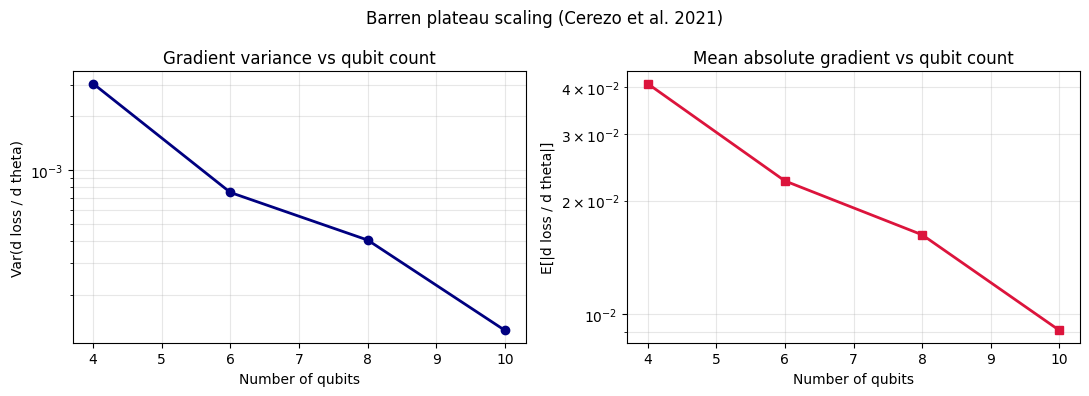


Conclusion: gradients decay exponentially with qubit count.
Beyond 6 qubits the signal-to-noise ratio at 512 shots becomes
insufficient for reliable training, which is why the main experiment
uses 6 qubits (64 configurations).


In [4]:
np.random.seed(42)

print("Barren plateau diagnosis")
print("Measuring gradient variance across different qubit counts")
print("This shows the well-known exponential decay of gradient magnitudes")
print("and motivates the choice of 6 qubits for the main experiment.")
print()


def synthetic_encoder(n_qubits: int) -> HyperparameterEncoder:
    n_per_param = 2 ** (n_qubits // 3 if n_qubits >= 3 else 1)
    leftover = n_qubits - 3 * int(math.log2(n_per_param))
    n_for_last = max(2, 2 ** max(1, leftover))
    space = {
        "alpha": {"type": "discrete",
                  "values": [round(0.1 * i, 4) for i in range(1, n_per_param + 1)]},
        "beta":  {"type": "discrete",
                  "values": [round(0.1 * i, 4) for i in range(1, n_per_param + 1)]},
        "gamma": {"type": "discrete",
                  "values": [round(0.1 * i, 4) for i in range(1, n_for_last + 1)]},
    }
    return HyperparameterEncoder(space)


qubit_counts = [4, 6, 8, 10]
barren = diagnose_barren_plateau(
    encoder_factory=synthetic_encoder,
    qubit_counts=qubit_counts,
    num_layers=2,
    n_samples=30,
    shots=512,
    random_seed=42,
)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].semilogy(barren["qubits"], barren["grad_variance"],
                  marker="o", color="navy", linewidth=2)
axes[0].set_title("Gradient variance vs qubit count")
axes[0].set_xlabel("Number of qubits")
axes[0].set_ylabel("Var(d loss / d theta)")
axes[0].grid(True, alpha=0.3, which="both")

axes[1].semilogy(barren["qubits"], barren["grad_mean_abs"],
                  marker="s", color="crimson", linewidth=2)
axes[1].set_title("Mean absolute gradient vs qubit count")
axes[1].set_xlabel("Number of qubits")
axes[1].set_ylabel("E[|d loss / d theta|]")
axes[1].grid(True, alpha=0.3, which="both")

plt.suptitle("Barren plateau scaling (Cerezo et al. 2021)")
plt.tight_layout()
plt.savefig("barren_plateau.png", dpi=150, bbox_inches="tight")
plt.show()

print()
print("Conclusion: gradients decay exponentially with qubit count.")
print("Beyond 6 qubits the signal-to-noise ratio at 512 shots becomes")
print("insufficient for reliable training, which is why the main experiment")
print("uses 6 qubits (64 configurations).")

Primary experiment: SVM on digits with low-data, noisy-label regime
  Training set: 50 samples (down from 1347)
  Label noise: 15 percent random reassignment
  Search space: 64 configurations (8 x 8 grid)
  C range: 0.001 to 10000 (7 orders of magnitude)
  gamma range: 0.0001 to 1000 (7 orders of magnitude)
  Qubits: 6, circuit parameters: 44
  Max possible entropy: 6.00 bits

Step 1: exhaustive search for ground truth
Running exhaustive search over 64 configurations
  Optimal score: 0.7204
  Optimal config: {'C': 100.0, 'gamma': 0.001}
  Configs within 95 percent of optimum: 9 / 64

Score distribution across all configurations:
  Mean: 0.2181, std: 0.2237
  Min:  0.1000, max: 0.7204
  Configs scoring above 0.7: 5 / 64
  Configs scoring above 0.5: 11 / 64

Top 5 configurations:
  0.7204  {'C': 100.0, 'gamma': 0.001}
  0.7204  {'C': 1000.0, 'gamma': 0.0001}
  0.7204  {'C': 1000.0, 'gamma': 0.001}
  0.7204  {'C': 10000.0, 'gamma': 0.0001}
  0.7204  {'C': 10000.0, 'gamma': 0.001}

Bottom 

VQC-BO:  76%|███████▌  | 19/25 [10:14<03:13, 32.32s/it, H=4.51, acq=0.0231(EI), best=0.7204]

Sampling exhausted

Quantum BO best score:  0.7204
Quantum BO best config: {'C': 100.0, 'gamma': 0.001}
Total evaluations:      61
Final entropy:          4.5126 bits (drop of 1.49 bits)
Runtime:                614.3s

Step 3: classical baselines (matched budget)


Random search:  0.7204 +/- 0.0000
GP-BO:          0.7204
Optuna TPE:     0.7204

Step 4: LLM surrogate baseline
Loading distilgpt2


tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Warm-start best: 0.6907


LLM-Surr: 100%|██████████| 10/10 [09:24<00:00, 56.44s/it, best=0.7204]


LLM surrogate best: 0.7204

Step 5: multi-seed quantum BO for statistical test
  seed 0: best=0.7204, H_final=3.11, runtime=444s
  seed 1: best=0.7204, H_final=1.85, runtime=459s
  seed 2: best=0.7204, H_final=1.13, runtime=399s
  seed 3: best=0.7204, H_final=1.48, runtime=395s
  seed 4: best=0.7204, H_final=4.00, runtime=566s
Multi-seed mean: 0.7204 +/- 0.0000

Results summary
  Ground truth optimum: 0.7204
  Configs within 95% of optimum: 9 / 64
  Quantum BO (VQC + GP):  0.7204
  GP-BO (scikit-optimize):0.7204
  Optuna TPE:             0.7204
  LLM surrogate:          0.7204
  Random search:          0.7204 (mean) +/- 0.0000

  Quantum BO evaluations: 61
  Quantum BO iterations:  19
  Final entropy:          4.5126 bits
  Max possible entropy:   6.00 bits
  Entropy drop:           1.49 bits
  Multi-seed mean:        0.7204 +/- 0.0000
  Mann-Whitney U=37.5, p=1.0000 (one-sided: quantum BO greater than random)


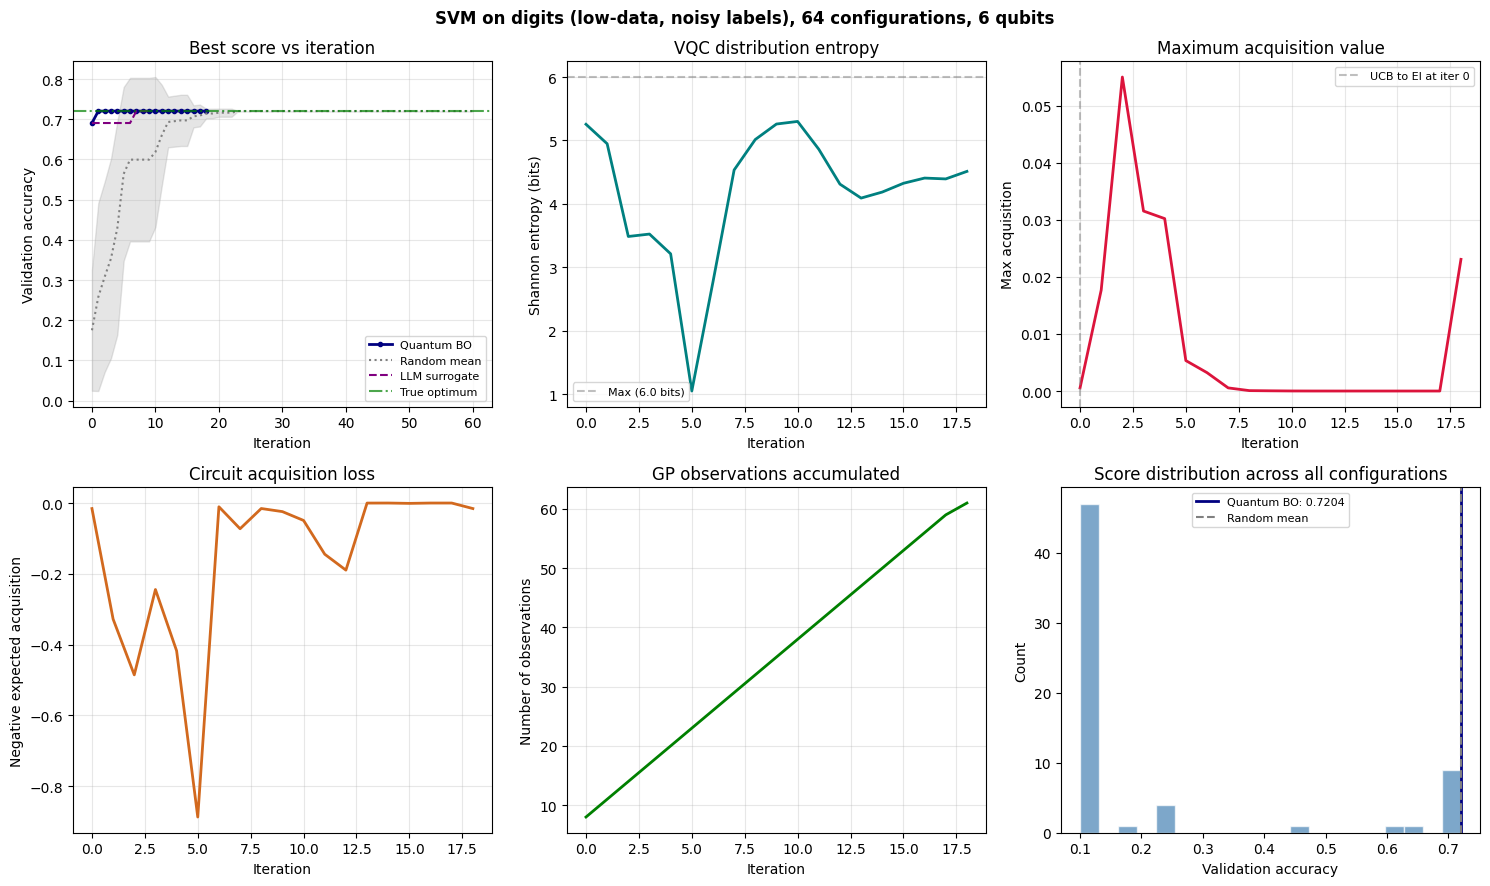

In [5]:
np.random.seed(42)

svm_search_space = {
    "C":     {"type": "discrete",
              "values": [0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0, 10000.0]},
    "gamma": {"type": "discrete",
              "values": [0.0001, 0.001, 0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]},
}

svm_objective = make_hard_svm_objective(
    random_seed=42, n_train_samples=50, label_noise_rate=0.15)
svm_bench = HPOBenchmark(svm_objective, svm_search_space, n_trials=15)
svm_encoder = HyperparameterEncoder(svm_search_space)
n_circuit_params = VariationalSurrogate(
    svm_encoder.total_qubits, 2, svm_encoder).get_num_parameters()

print(f"Primary experiment: SVM on digits with low-data, noisy-label regime")
print(f"  Training set: 50 samples (down from 1347)")
print(f"  Label noise: 15 percent random reassignment")
print(f"  Search space: {svm_encoder.total_configs} configurations "
      f"(8 x 8 grid)")
print(f"  C range: 0.001 to 10000 (7 orders of magnitude)")
print(f"  gamma range: 0.0001 to 1000 (7 orders of magnitude)")
print(f"  Qubits: {svm_encoder.total_qubits}, "
      f"circuit parameters: {n_circuit_params}")
print(f"  Max possible entropy: {math.log2(svm_encoder.total_configs):.2f} bits")
print()

print("Step 1: exhaustive search for ground truth")
svm_exhaustive = svm_bench.exhaustive_search()
print(f"  Optimal score: {svm_exhaustive['optimal_score']:.4f}")
print(f"  Optimal config: {svm_exhaustive['optimal_config']}")
print(f"  Configs within 95 percent of optimum: "
      f"{svm_exhaustive['n_within_95pct']} / {svm_encoder.total_configs}")
print()
print("Score distribution across all configurations:")
all_scores_arr = np.array(list(svm_exhaustive["all_scores"].values()))
print(f"  Mean: {all_scores_arr.mean():.4f}, "
      f"std: {all_scores_arr.std():.4f}")
print(f"  Min:  {all_scores_arr.min():.4f}, "
      f"max: {all_scores_arr.max():.4f}")
print(f"  Configs scoring above 0.7: "
      f"{int((all_scores_arr > 0.7).sum())} / {len(all_scores_arr)}")
print(f"  Configs scoring above 0.5: "
      f"{int((all_scores_arr > 0.5).sum())} / {len(all_scores_arr)}")
print()
print("Top 5 configurations:")
for cfg, s in svm_exhaustive["top5"]:
    print(f"  {s:.4f}  {cfg}")
print()
print("Bottom 3 configurations:")
all_sorted = sorted(svm_exhaustive["all_scores"].items(), key=lambda x: x[1])
for idx, s in all_sorted[:3]:
    print(f"  {s:.4f}  {svm_encoder.index_to_config(idx)}")

print()
print("Step 2: Quantum Bayesian Optimization")
svm_qbo = svm_bench.run_quantum_bo(
    num_layers=2,
    max_iterations=25,
    batch_size=3,
    grad_shots=512,
    sample_shots=1024,
    learning_rate=0.1,
    vqc_steps_per_iter=3,
    gradient_repeats=2,
    xi_start=0.05,
    xi_end=0.005,
    ucb_beta=2.0,
    entropy_threshold=1.5,
    acq_threshold=0.001,
    min_iter_before_convergence=8,
    max_time_seconds=7200,
    warm_start_n=5,
    verbose=True,
    random_seed=42,
)
print()
print(f"Quantum BO best score:  {svm_qbo['best_score']:.4f}")
print(f"Quantum BO best config: {svm_qbo['best_config']}")
print(f"Total evaluations:      {svm_qbo['total_evaluations']}")
print(f"Final entropy:          {svm_qbo['final_entropy']:.4f} bits "
      f"(drop of "
      f"{math.log2(svm_encoder.total_configs) - svm_qbo['final_entropy']:.2f} "
      f"bits)")
print(f"Runtime:                {svm_qbo['runtime_sec']:.1f}s")

print()
print("Step 3: classical baselines (matched budget)")
budget = svm_qbo["total_evaluations"]
svm_random = svm_bench.run_random_search(budget)
print(f"Random search:  {np.mean(svm_random['trial_best_scores']):.4f} "
      f"+/- {np.std(svm_random['trial_best_scores']):.4f}")
svm_gp_bo = svm_bench.run_gp_bo(budget, random_seed=42)
print(f"GP-BO:          {svm_gp_bo['best_score']:.4f}")
svm_tpe = svm_bench.run_tpe(budget, random_seed=42)
print(f"Optuna TPE:     {svm_tpe['best_score']:.4f}")

print()
print("Step 4: LLM surrogate baseline")
svm_llm = svm_bench.run_llm_surrogate(
    model_name="distilgpt2",
    max_iterations=10,
    batch_size=3,
    warm_start_n=5,
    temperature=0.8,
    verbose=True,
    random_seed=42,
)
print(f"LLM surrogate best: {svm_llm['best_score']:.4f}")

print()
print("Step 5: multi-seed quantum BO for statistical test")
svm_qbo_multi = svm_bench.run_quantum_bo_multi_seed(
    n_seeds=5,
    num_layers=2,
    max_iterations=20,
    batch_size=3,
    grad_shots=512,
    sample_shots=1024,
    learning_rate=0.1,
    vqc_steps_per_iter=3,
    gradient_repeats=2,
    xi_start=0.05,
    xi_end=0.005,
    ucb_beta=2.0,
    entropy_threshold=1.5,
    acq_threshold=0.001,
    min_iter_before_convergence=8,
    max_time_seconds=4500,
    warm_start_n=5,
)
print(f"Multi-seed mean: {np.mean(svm_qbo_multi):.4f} "
      f"+/- {np.std(svm_qbo_multi):.4f}")

svm_report = svm_bench.report(
    svm_qbo, svm_random, svm_gp_bo, svm_tpe, svm_llm,
    qbo_multi=svm_qbo_multi, exhaustive=svm_exhaustive,
)

svm_bench.plot_diagnostics(
    svm_qbo,
    random_results=svm_random,
    exhaustive=svm_exhaustive,
    llm_result=svm_llm,
    title="SVM on digits (low-data, noisy labels), 64 configurations, 6 qubits",
)

In [6]:
np.random.seed(42)

rf_search_space = {
    "n_estimators":      {"type": "discrete", "values": [50, 100, 200, 400]},
    "max_depth":         {"type": "discrete", "values": [3, 5, 8, 12]},
    "min_samples_split": {"type": "discrete", "values": [2, 5, 10, 20]},
}

rf_objective = make_random_forest_objective(random_seed=42)
rf_bench = HPOBenchmark(rf_objective, rf_search_space, n_trials=15)
rf_encoder = HyperparameterEncoder(rf_search_space)

print(f"Secondary experiment: Random Forest on breast cancer")
print(f"  Search space: {rf_encoder.total_configs} configurations")
print(f"  Qubits: {rf_encoder.total_qubits}")
print()

print("Exhaustive search")
rf_exhaustive = rf_bench.exhaustive_search()
print(f"  Optimal score: {rf_exhaustive['optimal_score']:.4f}")
print(f"  Optimal config: {rf_exhaustive['optimal_config']}")

print()
print("Quantum BO")
rf_qbo = rf_bench.run_quantum_bo(
    num_layers=2,
    max_iterations=25,
    batch_size=3,
    grad_shots=512,
    sample_shots=1024,
    learning_rate=0.1,
    vqc_steps_per_iter=3,
    gradient_repeats=2,
    entropy_threshold=1.5,
    acq_threshold=0.001,
    min_iter_before_convergence=8,
    max_time_seconds=5400,
    warm_start_n=5,
    verbose=True,
    random_seed=42,
)
print(f"Quantum BO best: {rf_qbo['best_score']:.4f}, "
      f"config: {rf_qbo['best_config']}")

budget = rf_qbo["total_evaluations"]
print()
print(f"Classical baselines (budget = {budget})")
rf_random = rf_bench.run_random_search(budget)
print(f"Random search:  {np.mean(rf_random['trial_best_scores']):.4f} "
      f"+/- {np.std(rf_random['trial_best_scores']):.4f}")
rf_gp_bo = rf_bench.run_gp_bo(budget, random_seed=42)
print(f"GP-BO:          {rf_gp_bo['best_score']:.4f}")
rf_tpe = rf_bench.run_tpe(budget, random_seed=42)
print(f"Optuna TPE:     {rf_tpe['best_score']:.4f}")

print()
print("LLM surrogate")
rf_llm = rf_bench.run_llm_surrogate(
    model_name="distilgpt2",
    max_iterations=10,
    batch_size=3,
    warm_start_n=5,
    temperature=0.8,
    verbose=False,
    random_seed=42,
)
print(f"LLM surrogate best: {rf_llm['best_score']:.4f}")

rf_report = rf_bench.report(
    rf_qbo, rf_random, rf_gp_bo, rf_tpe, rf_llm,
    exhaustive=rf_exhaustive,
)

Secondary experiment: Random Forest on breast cancer
  Search space: 64 configurations
  Qubits: 6

Exhaustive search
Running exhaustive search over 64 configurations
  Optimal score: 0.9580
  Optimal config: {'n_estimators': 50, 'max_depth': 3, 'min_samples_split': 5}

Quantum BO
Search space: 64 configs, 6 qubits, 46 circuit parameters
Max possible entropy: 6.00 bits
Warm-starting with 5 evaluations
Warm-start best score: 0.9580
Running 25 optimization iterations


VQC-BO:  76%|███████▌  | 19/25 [02:14<00:42,  7.08s/it, H=5.11, acq=0.0000(EI), best=0.9580]

Sampling exhausted
Quantum BO best: 0.9580, config: {'n_estimators': 200, 'max_depth': 8, 'min_samples_split': 10}

Classical baselines (budget = 62)


Random search:  0.9580 +/- 0.0000
GP-BO:          0.9580
Optuna TPE:     0.9580

LLM surrogate


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


LLM surrogate best: 0.9580

Results summary
  Ground truth optimum: 0.9580
  Configs within 95% of optimum: 64 / 64
  Quantum BO (VQC + GP):  0.9580
  GP-BO (scikit-optimize):0.9580
  Optuna TPE:             0.9580
  LLM surrogate:          0.9580
  Random search:          0.9580 (mean) +/- 0.0000

  Quantum BO evaluations: 62
  Quantum BO iterations:  19
  Final entropy:          5.1082 bits
  Max possible entropy:   6.00 bits
  Entropy drop:           0.89 bits
  Mann-Whitney U=7.5, p=1.0000 (one-sided: quantum BO greater than random)


Noise resilience: depolarizing error on all gates
  p=0.000: best=0.7204, H_final=1.824, runtime=493s
  p=0.005: best=0.7204, H_final=1.559, runtime=397s
  p=0.010: best=0.7204, H_final=1.089, runtime=396s
  p=0.020: best=0.7204, H_final=1.662, runtime=489s

LLM decoding temperature ablation


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  T=0.3: best=0.7204, evals=35


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  T=0.6: best=0.7204, evals=35


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  T=0.9: best=0.7204, evals=35


/usr/local/lib/python3.12/dist-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


  T=1.2: best=0.7204, evals=35


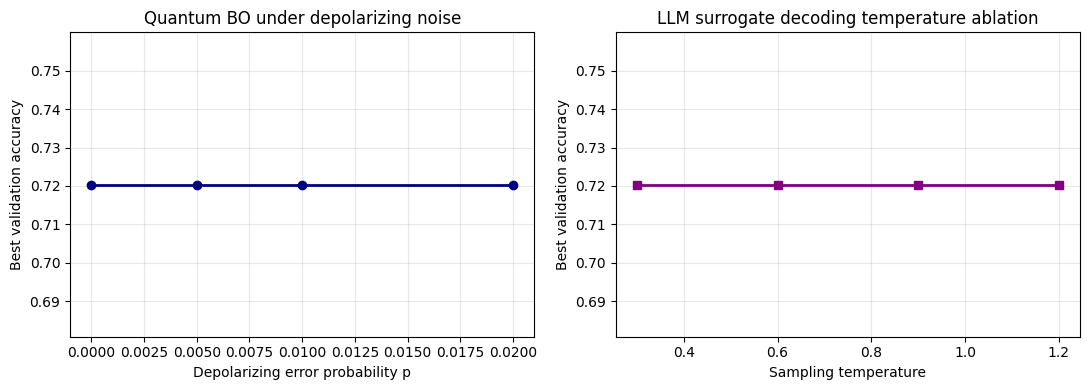

In [7]:
np.random.seed(42)

print("Noise resilience: depolarizing error on all gates")
noise_levels = [0.0, 0.005, 0.01, 0.02]
noise_results = {}
for p in noise_levels:
    nm = None if p == 0.0 else create_depolarizing_noise(p)
    r = QuantumBayesianOptimizer(
        svm_objective, svm_search_space,
        num_layers=2, max_iterations=20, batch_size=3,
        grad_shots=512, sample_shots=1024,
        learning_rate=0.1, vqc_steps_per_iter=3,
        gradient_repeats=2, noise_model=nm,
        entropy_threshold=1.5, acq_threshold=0.001,
        min_iter_before_convergence=8,
        max_time_seconds=3600,
        warm_start_n=5, verbose=False, random_seed=42,
    ).optimize()
    noise_results[p] = r
    print(f"  p={p:.3f}: best={r['best_score']:.4f}, "
          f"H_final={r['final_entropy']:.3f}, "
          f"runtime={r['runtime_sec']:.0f}s")

print()
print("LLM decoding temperature ablation")
temperatures = [0.3, 0.6, 0.9, 1.2]
temperature_results = {}
for T in temperatures:
    r = LLMSurrogateOptimizer(
        svm_objective, svm_search_space,
        model_name="distilgpt2",
        max_iterations=10, batch_size=3,
        warm_start_n=5, temperature=T,
        verbose=False, random_seed=42,
    ).optimize()
    temperature_results[T] = r
    print(f"  T={T:.1f}: best={r['best_score']:.4f}, "
          f"evals={r['total_evaluations']}")

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(list(noise_results.keys()),
             [r["best_score"] for r in noise_results.values()],
             marker="o", color="navy", linewidth=2)
axes[0].set_title("Quantum BO under depolarizing noise")
axes[0].set_xlabel("Depolarizing error probability p")
axes[0].set_ylabel("Best validation accuracy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(temperature_results.keys()),
             [r["best_score"] for r in temperature_results.values()],
             marker="s", color="purple", linewidth=2)
axes[1].set_title("LLM surrogate decoding temperature ablation")
axes[1].set_xlabel("Sampling temperature")
axes[1].set_ylabel("Best validation accuracy")
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("ablations.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
print("Project summary")
print()
print("Architecture: Quantum Bayesian Optimization with a variational")
print("circuit acquisition function optimizer.")
print()
print("Tools and frameworks:")
print("  Qiskit and Qiskit-Aer: circuit construction, parameter-shift")
print("    gradients, shot-based evaluation, barren plateau diagnosis,")
print("    depolarizing noise simulation")
print("  scikit-learn: SVM and Random Forest objectives, Matern-5/2 GP")
print("    surrogate via GaussianProcessRegressor")
print("  scikit-optimize: classical GP-BO baseline with expected improvement")
print("  Optuna: TPE optimizer baseline")
print("  HuggingFace Transformers: distilgpt2 surrogate conditioned on")
print("    prior configuration-score pairs as text prompts, with")
print("    decoding temperature controlled directly")
print("  PyTorch: backend for the language model surrogate")
print("  NumPy, SciPy, Matplotlib: numerics, statistics and visualisation")
print()
print("Genuinely quantum components:")
print("  Parameter-shift rule gradients (Schuld et al. 2019), exact")
print("  Shots-based sampling via Qiskit Aer; noise affects selection")
print("  CRZ entanglement gates at parameter boundaries capture")
print("    cross-parameter correlations")
print("  Variational circuit trained on the GP acquisition surface,")
print("    not the raw reward")
print("  Batch sampling from the quantum distribution, in contrast to")
print("    sequential classical BO")
print("  Shannon entropy of the measurement distribution as a")
print("    convergence diagnostic")
print()
try:
    print("Primary results (SVM on digits, 64 configurations):")
    print(f"  Ground truth optimum: {svm_exhaustive['optimal_score']:.4f}")
    print(f"  Quantum BO:           {svm_qbo['best_score']:.4f} "
          f"({svm_qbo['total_evaluations']} evals)")
    print(f"  GP-BO:                {svm_gp_bo['best_score']:.4f}")
    print(f"  Optuna TPE:           {svm_tpe['best_score']:.4f}")
    print(f"  LLM surrogate:        {svm_llm['best_score']:.4f}")
    print(f"  Random search mean:   {np.mean(svm_random['trial_best_scores']):.4f}")
    print(f"  Multi-seed quantum BO: {np.mean(svm_qbo_multi):.4f} "
          f"+/- {np.std(svm_qbo_multi):.4f}")
    print(f"  Mann-Whitney p-value: {svm_report['p_value']:.4f}")
    me = math.log2(svm_encoder.total_configs)
    print(f"  VQC entropy collapse: {me:.2f} bits to "
          f"{svm_qbo['final_entropy']:.2f} bits "
          f"({me - svm_qbo['final_entropy']:.2f} bit drop)")
except NameError:
    print("  Run Cell 5 first")
print()
try:
    print("Secondary results (Random Forest on breast cancer):")
    print(f"  Ground truth optimum: {rf_exhaustive['optimal_score']:.4f}")
    print(f"  Quantum BO:           {rf_qbo['best_score']:.4f}")
    print(f"  GP-BO:                {rf_gp_bo['best_score']:.4f}")
    print(f"  Optuna TPE:           {rf_tpe['best_score']:.4f}")
    print(f"  LLM surrogate:        {rf_llm['best_score']:.4f}")
    print(f"  Random search mean:   {np.mean(rf_random['trial_best_scores']):.4f}")
except NameError:
    print("  Run Cell 6 first")
print()
print("References")
print("  Cerezo et al. (2021). Variational quantum algorithms.")
print("    Nature Reviews Physics 3, 625-644.")
print("  Schuld et al. (2019). Evaluating analytic gradients on quantum")
print("    hardware. Physical Review A 99, 032331.")
print("  Shahriari et al. (2016). Taking the human out of the loop:")
print("    A review of Bayesian optimization. Proc. IEEE 104(1), 148-175.")
print("  Snoek, Larochelle and Adams (2012). Practical Bayesian optimization")
print("    of machine learning algorithms. NeurIPS.")

Project summary

Architecture: Quantum Bayesian Optimization with a variational
circuit acquisition function optimizer.

Tools and frameworks:
  Qiskit and Qiskit-Aer: circuit construction, parameter-shift
    gradients, shot-based evaluation, barren plateau diagnosis,
    depolarizing noise simulation
  scikit-learn: SVM and Random Forest objectives, Matern-5/2 GP
    surrogate via GaussianProcessRegressor
  scikit-optimize: classical GP-BO baseline with expected improvement
  Optuna: TPE optimizer baseline
  HuggingFace Transformers: distilgpt2 surrogate conditioned on
    prior configuration-score pairs as text prompts, with
    decoding temperature controlled directly
  PyTorch: backend for the language model surrogate
  NumPy, SciPy, Matplotlib: numerics, statistics and visualisation

Genuinely quantum components:
  Parameter-shift rule gradients (Schuld et al. 2019), exact
  Shots-based sampling via Qiskit Aer; noise affects selection
  CRZ entanglement gates at parameter boundar

In [9]:
np.random.seed(42)

print("Sample-efficiency experiment: small evaluation budget on hard SVM")
print("With only 10 evals out of 64, random search should genuinely struggle.")
print("This is where quantum BO's directed search should show an advantage.")
print()

TIGHT_BUDGET = 10

print(f"Step 1: random search at budget = {TIGHT_BUDGET}, "
      f"averaged over 15 trials")
svm_random_tight = svm_bench.run_random_search(TIGHT_BUDGET)
rand_scores = svm_random_tight["trial_best_scores"]
print(f"  Random search: mean = {np.mean(rand_scores):.4f}, "
      f"std = {np.std(rand_scores):.4f}")
print(f"  Min: {np.min(rand_scores):.4f}, max: {np.max(rand_scores):.4f}")
print(f"  Trials reaching optimum (0.7204): "
      f"{int(sum(s >= 0.72 for s in rand_scores))} / {len(rand_scores)}")

print()
print(f"Step 2: GP-BO at budget = {TIGHT_BUDGET}")
gp_bo_scores_tight = []
for seed in range(5):
    r = svm_bench.run_gp_bo(TIGHT_BUDGET, random_seed=seed)
    gp_bo_scores_tight.append(r["best_score"])
    print(f"  seed {seed}: {r['best_score']:.4f}")
print(f"  GP-BO: mean = {np.mean(gp_bo_scores_tight):.4f}, "
      f"std = {np.std(gp_bo_scores_tight):.4f}")

print()
print(f"Step 3: Optuna TPE at budget = {TIGHT_BUDGET}")
tpe_scores_tight = []
for seed in range(5):
    r = svm_bench.run_tpe(TIGHT_BUDGET, random_seed=seed)
    tpe_scores_tight.append(r["best_score"])
    print(f"  seed {seed}: {r['best_score']:.4f}")
print(f"  Optuna TPE: mean = {np.mean(tpe_scores_tight):.4f}, "
      f"std = {np.std(tpe_scores_tight):.4f}")

print()
print(f"Step 4: Quantum BO at budget = {TIGHT_BUDGET}, 5 seeds")
qbo_scores_tight = svm_bench.run_quantum_bo_multi_seed(
    n_seeds=5,
    num_layers=2,
    max_iterations=2,
    batch_size=3,
    grad_shots=512,
    sample_shots=1024,
    learning_rate=0.1,
    vqc_steps_per_iter=3,
    gradient_repeats=2,
    xi_start=0.05,
    xi_end=0.005,
    ucb_beta=2.0,
    entropy_threshold=0.5,
    acq_threshold=0.001,
    min_iter_before_convergence=2,
    max_time_seconds=900,
    warm_start_n=4,
)
print(f"  Quantum BO: mean = {np.mean(qbo_scores_tight):.4f}, "
      f"std = {np.std(qbo_scores_tight):.4f}")

print()
print("Sample-efficiency comparison at fixed small budget")
print(f"  Budget: {TIGHT_BUDGET} evaluations out of 64 ({TIGHT_BUDGET/64*100:.0f}% coverage)")
print(f"  Random search:  {np.mean(rand_scores):.4f} +/- {np.std(rand_scores):.4f}")
print(f"  GP-BO:          {np.mean(gp_bo_scores_tight):.4f} +/- {np.std(gp_bo_scores_tight):.4f}")
print(f"  Optuna TPE:     {np.mean(tpe_scores_tight):.4f} +/- {np.std(tpe_scores_tight):.4f}")
print(f"  Quantum BO:     {np.mean(qbo_scores_tight):.4f} +/- {np.std(qbo_scores_tight):.4f}")

print()
u_q_rand, p_q_rand = mannwhitneyu(
    np.array(qbo_scores_tight), np.array(rand_scores),
    alternative="greater")
print(f"Quantum BO vs random:  U = {u_q_rand:.1f}, p = {p_q_rand:.4f}")

u_q_gp, p_q_gp = mannwhitneyu(
    np.array(qbo_scores_tight), np.array(gp_bo_scores_tight),
    alternative="greater")
print(f"Quantum BO vs GP-BO:   U = {u_q_gp:.1f}, p = {p_q_gp:.4f}")

u_q_tpe, p_q_tpe = mannwhitneyu(
    np.array(qbo_scores_tight), np.array(tpe_scores_tight),
    alternative="greater")
print(f"Quantum BO vs Optuna:  U = {u_q_tpe:.1f}, p = {p_q_tpe:.4f}")

Sample-efficiency experiment: small evaluation budget on hard SVM
With only 10 evals out of 64, random search should genuinely struggle.
This is where quantum BO's directed search should show an advantage.

Step 1: random search at budget = 10, averaged over 15 trials
  Random search: mean = 0.6812, std = 0.1155
  Min: 0.2519, max: 0.7204
  Trials reaching optimum (0.7204): 10 / 15

Step 2: GP-BO at budget = 10
  seed 0: 0.2519
  seed 1: 0.6907
  seed 2: 0.6907
  seed 3: 0.7204
  seed 4: 0.7204
  GP-BO: mean = 0.6148, std = 0.1820

Step 3: Optuna TPE at budget = 10
  seed 0: 0.7204
  seed 1: 0.7204
  seed 2: 0.7204
  seed 3: 0.6148
  seed 4: 0.7204
  Optuna TPE: mean = 0.6993, std = 0.0422

Step 4: Quantum BO at budget = 10, 5 seeds
  seed 0: best=0.7204, H_final=4.26, runtime=63s
  seed 1: best=0.1000, H_final=3.32, runtime=63s
  seed 2: best=0.1000, H_final=3.36, runtime=64s
  seed 3: best=0.2519, H_final=3.16, runtime=64s
  seed 4: best=0.7204, H_final=5.22, runtime=64s
  Quantum BO